In [163]:
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import numpy as np

import apimoex
import pandas as pd

## OFZ-IN data

In [211]:
IN_tickers = [
    'SU52001RMFS3',
    'SU52002RMFS1',
    'SU52003RMFS9',
    'SU52004RMFS7',
    'SU52005RMFS4',
]


def download_data(number):
    data = apimoex.get_board_history(
        session, security=IN_tickers[number - 1], market='bonds', board='TQOB'
    )
    df = pd.DataFrame(data)
    df.drop(['BOARDID', 'VOLUME', 'VALUE'], axis=1, inplace=True)
    df.rename(columns={'TRADEDATE': 'date', 'CLOSE': f'price_in-{number}'}, inplace=True)
    df['date'] = df['date'].apply(lambda date: datetime.strptime(date, '%Y-%m-%d'))
    df.set_index('date', inplace=True)
    return df

N_IN = 5

In [245]:
IN_data = None

with requests.Session() as session:
    for i in range(len(IN_tickers)):
        new_df = download_data(number=i+1)
        if IN_data is None:
            IN_data = new_df
        else:
            IN_data = IN_data.merge(new_df, on='date', how='outer')
            

maturity = {
    1: datetime.strptime('2023-08-16', '%Y-%m-%d'),
    2: datetime.strptime('2028-02-02', '%Y-%m-%d'),
    3: datetime.strptime('2030-07-17', '%Y-%m-%d'),
    4: datetime.strptime('2032-03-17', '%Y-%m-%d'),
    5: datetime.strptime('2033-05-11', '%Y-%m-%d'),
}

issuance_time = {
    number: IN_data[f'price_in-{number}'].dropna().index.min()
    for number in range(1, N_IN + 1)
}

## CPI

In [246]:
CPI = pd.read_csv('data/CPI.csv')
CPI.set_index('month', inplace=True)

CPI = CPI.stack().reset_index()
CPI.columns = ['month', 'year', 'Inflation']

CPI['date'] = pd.to_datetime(
    CPI['year'].astype(str) + '-' + CPI['month'].astype(str),
    format='%Y-%m'
) + pd.offsets.MonthEnd(0)
CPI.drop(columns=['month', 'year'], inplace=True)

CPI.set_index('date', inplace=True)

CPI.loc[datetime(year=2015, month=1, day=1)] = [100.0]
CPI.sort_values(by='date', inplace=True)
CPI['CPI'] = (CPI['Inflation'] / 100).cumprod() * 100
CPI.drop(columns=['Inflation'], inplace=True)
CPI = CPI.reindex(
        pd.date_range(
            start=CPI.index.min(), 
            end=CPI.index.max(), 
            freq='D'
        )
    ).interpolate(method='linear')

IN_data = IN_data.merge(CPI, left_index=True, right_index=True, how='left')
IN_data

,price_in-1,price_in-2,price_in-3,price_in-4,price_in-5,CPI
date,,,,,,
2015-07-17,93.7000,NaN,NaN,NaN,NaN,108.993815
2015-07-20,93.5000,NaN,NaN,NaN,NaN,109.077829
2015-07-21,94.5000,NaN,NaN,NaN,NaN,109.105833
2015-07-22,94.8900,NaN,NaN,NaN,NaN,109.133838
2015-07-23,94.6501,NaN,NaN,NaN,NaN,109.161843
...,...,...,...,...,...,...
2025-10-28,NaN,85.520,77.056,72.098,68.934,NaN
2025-10-29,NaN,85.532,76.933,72.110,69.049,NaN
2025-10-30,NaN,85.588,76.985,71.977,68.827,NaN


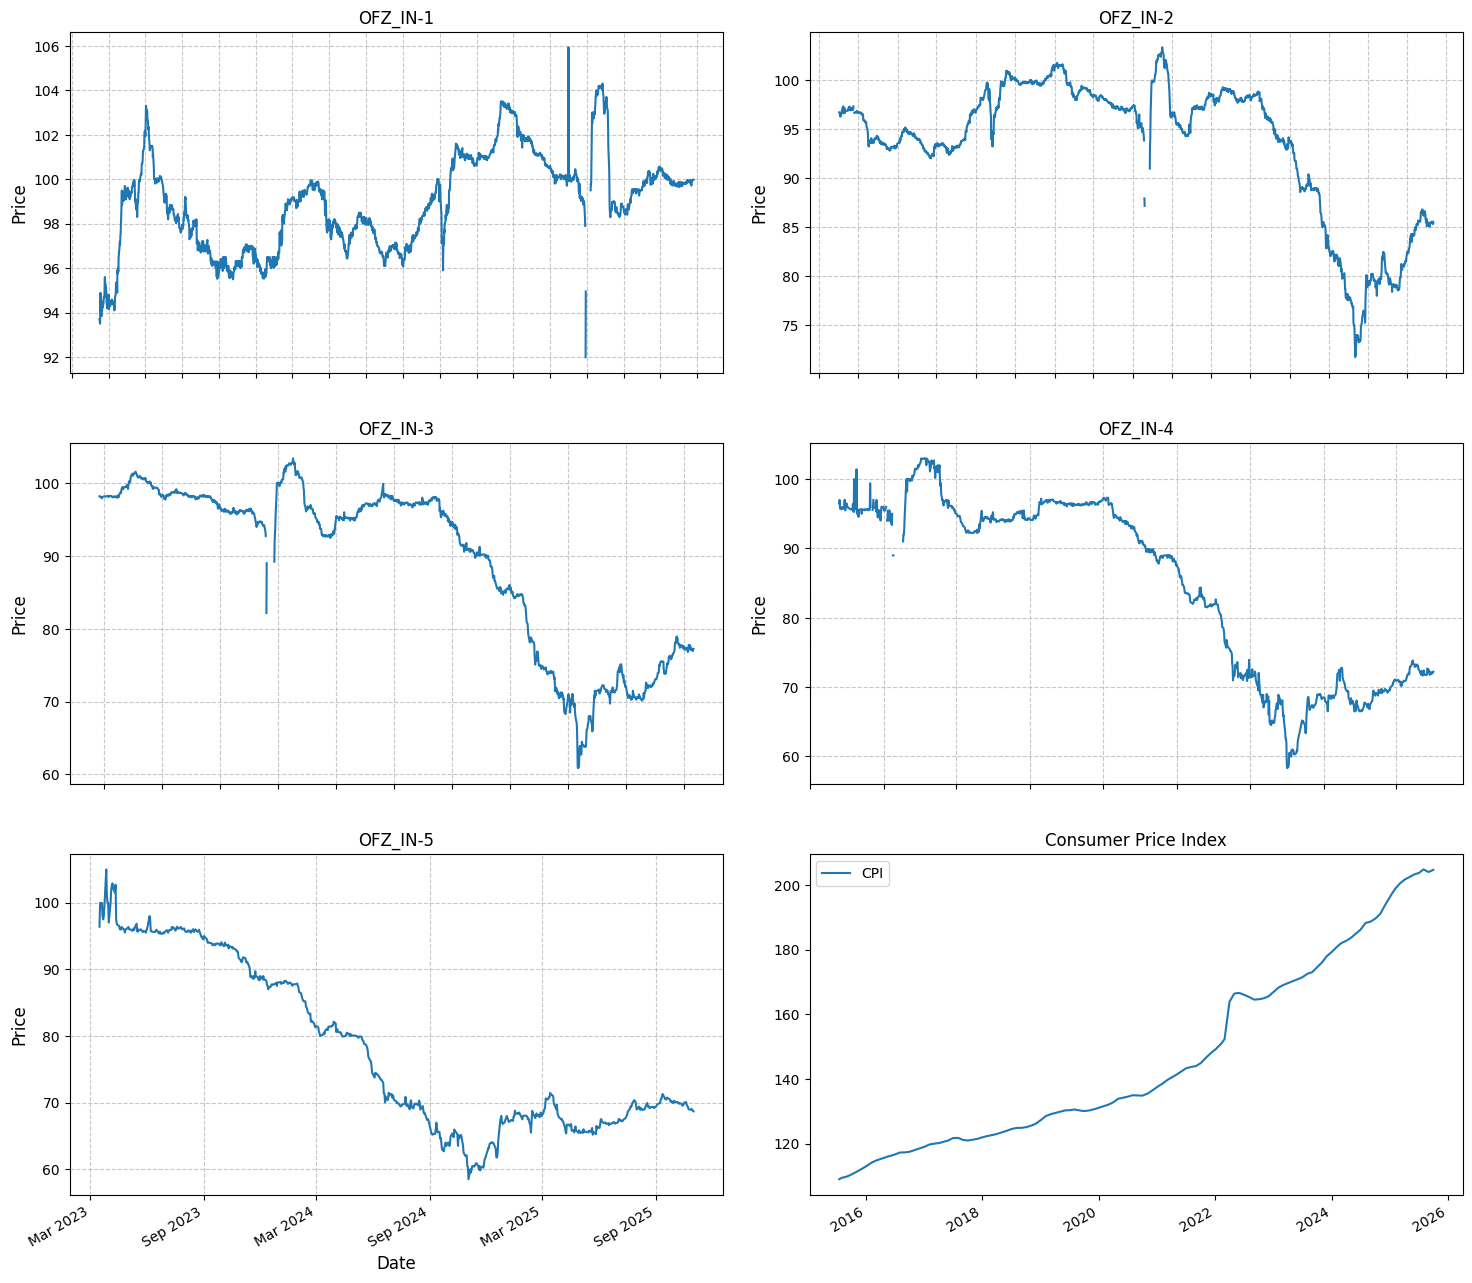

In [247]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

for i in range(5):
    x = i // 2
    y = i % 2
    axes[x][y].plot(IN_data[f'price_in-{i+1}'])

    half_year_locator = mdates.MonthLocator(interval=6)
    year_month_formatter = mdates.DateFormatter("%b %Y")
    axes[x][y].xaxis.set_major_locator(half_year_locator)
    axes[x][y].xaxis.set_major_formatter(year_month_formatter)

    axes[x][y].set_xlabel("Date", fontsize=12)
    axes[x][y].set_ylabel("Price", fontsize=12)
    axes[x][y].set_title(f'OFZ_IN-{i+1}'.upper())
    axes[x][y].grid(True, linestyle='--', alpha=0.7)


axes[2][1].set_title(f'Consumer Price Index', fontsize=12)
axes[2][1].plot(IN_data['CPI'], label='CPI')
axes[2][1].legend(loc='best')  
    
plt.tight_layout()
fig.autofmt_xdate()
plt.show()

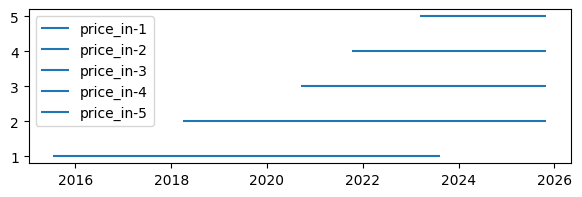

In [248]:
fig, ax = plt.subplots(figsize=(7, 2))

for number in range(1, N_IN + 1):
    key = f'price_in-{number}'
    xmin = IN_data[key].dropna().index.min()
    xmax = IN_data[key].dropna().index.max()

    ax.hlines(y=number, xmin=xmin, xmax=xmax, label=key)


ax.legend(loc='upper left')
plt.show()

## Coupons

In [249]:
def get_coupons_dates(number):
    ticker = IN_tickers[number - 1]
    with open(f'data/coupons_in-{number}.csv') as file:
        coupons = pd.read_csv(file)
        coupons['date'] = coupons['date'].apply(lambda date: datetime.strptime(date, '%Y-%m-%d'))
        coupons.sort_values(by='date', inplace=True)
        return coupons['date']
    
coupon_dates = {
    number: get_coupons_dates(number) for number in range(1, N_IN + 1)
}

## JY Model Calibration

We use the data for IN-3, IN-4, and IN-5 bonds from 2023-03-16 to 2025-11-01. There are three different TIPS price observations, so the forward rate curve will be estimated with a two-step pieswise constant function. The bounds are: $[0, 1Y], [1Y, +\infty]$ (can be changed).

In [256]:
C = 2.5 # in %
F = 100 # in %
m = 2 # semi-annual payments

start_date = IN_data['price_in-5'].dropna().index.min() # datetime.strptime('2023-03-16', '%Y-%m-%d')
end_date = datetime.strptime('2025-11-01', '%Y-%m-%d')

forward_rate_curve = pd.DataFrame(
    index=IN_data['price_in-5'].dropna().index,
    columns=['0-1Y', '1Y-inf'],
)

In [275]:
def calculate_TIPS_bond_price(number, t):
    if t > maturity[number]:
        return None
    value = 0.0
    for date in coupon_dates[number]:
        if date < t:
            continue
        value += C / m * IN_data.loc[t]['CPI'] * ZC_TIPS_bond_price(t, date)
    value += F * IN_data.loc[t]['CPI'] * ZC_TIPS_bond_price(t, maturity[number])
    price = value / IN_data.loc[issuance_time[number]]['CPI']
    nominal = F * IN_data.loc[t]['CPI'] / IN_data.loc[issuance_time[number]]['CPI']
    return price / nominal * 100

def ZC_TIPS_bond_price(t, T):
    delta_days = (T - t).days
    sr_rate, lr_rate = forward_rate_curve.loc[t]
    if delta_days < 365:
        return np.exp(-sr_rate * delta_days / 365)
    else:
        return np.exp(-sr_rate - lr_rate * (delta_days - 365) / 365)

In [286]:
forward_rate_curve.loc[start_date] = [0.1, 0.1]

ZC_TIPS_bond_price(start_date, start_date + timedelta(days=365))

np.float64(0.9048374180359595)

In [288]:
calculate_TIPS_bond_price(3, start_date)

np.float64(61.0423980096939)

In [279]:
IN_data.loc[start_date]

price_in-1    100.334000
price_in-2     98.895000
price_in-3     97.992000
price_in-4     96.591000
price_in-5     96.399000
CPI           169.306614
Name: 2023-03-16 00:00:00, dtype: float64